In [11]:
# Proposal-faithful RQ1 artifact generator
#
# This script reads frozen Phase 1 and Phase 2 outputs and generates only the
# exact proposal-facing RQ1 artifacts in a separate reporting layer.

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import precision_recall_curve


sns.set_theme(style="whitegrid")


# Update these paths in Kaggle before running.
PHASE1_INPUT_ROOT = Path("/kaggle/input/datasets/ashwinwalunj/ashwin-thesis-outputs/thesis_outputs")
PHASE2_INPUT_ROOT = Path("/kaggle/input/datasets/ashwinwalunj/ashwin-thesis-outputs-phase2/thesis_outputs")
OUTPUT_ROOT = Path("/kaggle/working/thesis_outputs")

RQ = "rq1"
RQ_OUTPUT_ROOT = OUTPUT_ROOT / "results_proposal" / RQ
FIGURES_ROOT = RQ_OUTPUT_ROOT / "figures"
TABLES_ROOT = RQ_OUTPUT_ROOT / "tables"
for folder in [FIGURES_ROOT, TABLES_ROOT]:
    folder.mkdir(parents=True, exist_ok=True)

ANALYST_BUDGETS = [100, 250, 500, 1000, 2500, 5000]


def save_table(df, name):
    df.to_csv(TABLES_ROOT / f"{name}.csv", index=False)


def save_figure(fig, name):
    fig.savefig(FIGURES_ROOT / f"{name}.png", dpi=300, bbox_inches="tight")
    fig.savefig(FIGURES_ROOT / f"{name}.pdf", bbox_inches="tight")
    plt.show()


def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def recall_at_k(y_true, y_score, k):
    sorted_idx = np.argsort(-y_score)[:k]
    positives = max(int(np.sum(y_true)), 1)
    return float(np.sum(y_true[sorted_idx]) / positives)

In [12]:
# Frozen inputs
phase1_metrics = load_json(
    PHASE1_INPUT_ROOT / "artifacts" / "phase01_data_baselines" / "baseline_metrics.json"
)
phase1_lgbm_history = load_json(
    PHASE1_INPUT_ROOT / "artifacts" / "phase01_data_baselines" / "lgbm_eval_history.json"
)
phase1_xgb_history = load_json(
    PHASE1_INPUT_ROOT / "artifacts" / "phase01_data_baselines" / "xgb_eval_history.json"
)

phase2_summary = pd.read_csv(
    PHASE2_INPUT_ROOT / "artifacts" / "phase02_graph_models" / "rq1_graph_model_summary.csv"
)
phase2_predictions = pd.read_parquet(
    PHASE2_INPUT_ROOT / "artifacts" / "phase02_graph_models" / "rq1_predictions.parquet"
)

In [13]:
# Table 1.1 - Performance Comparison
table_1_1_rows = [
    {
        "Model": "LightGBM",
        "AUC-ROC": phase1_metrics["test_lgbm_auc_roc"],
        "AUC-PR": phase1_metrics["test_lgbm_auc_pr"],
        "Recall@1%FPR": phase1_metrics["test_lgbm_recall_at_1pct_fpr"],
        "Latency(ms)": phase1_metrics["test_lgbm_latency_ms"],
    },
    {
        "Model": "XGBoost",
        "AUC-ROC": phase1_metrics["test_xgb_auc_roc"],
        "AUC-PR": phase1_metrics["test_xgb_auc_pr"],
        "Recall@1%FPR": phase1_metrics["test_xgb_recall_at_1pct_fpr"],
        "Latency(ms)": phase1_metrics["test_xgb_latency_ms"],
    },
]

for _, row in phase2_summary.iterrows():
    if row["variant_name"] != "full":
        continue
    table_1_1_rows.append(
        {
            "Model": row["model_name"],
            "AUC-ROC": row["test_auc_roc"],
            "AUC-PR": row["test_auc_pr"],
            "Recall@1%FPR": row["test_recall_at_1pct_fpr"],
            "Latency(ms)": row["test_latency_ms"],
        }
    )

table_1_1 = pd.DataFrame(table_1_1_rows)
save_table(table_1_1, "table_1_1_performance_comparison")

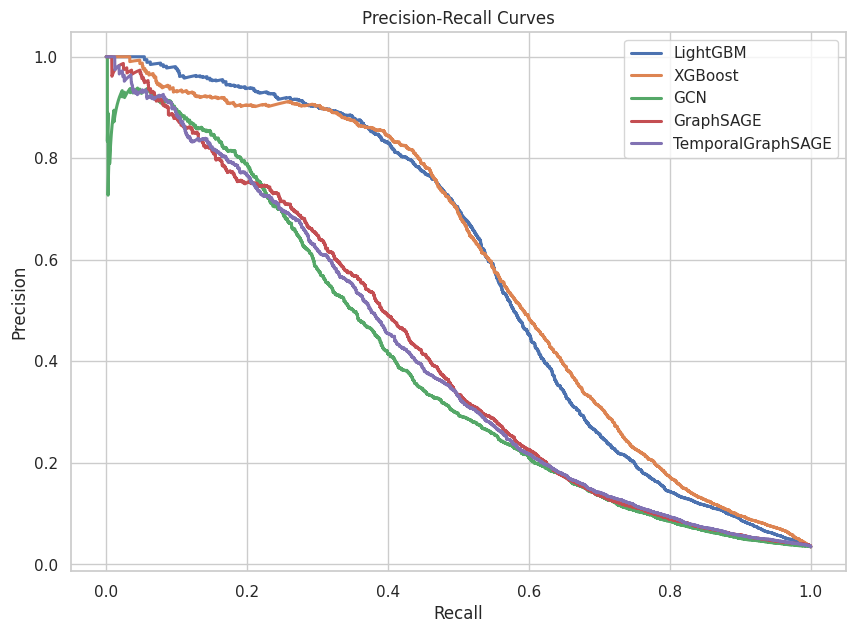

In [14]:
# Figure 1.1 - Precision-Recall Curves
test_prediction_df = phase2_predictions[phase2_predictions["split"] == "test"].copy()
y_test = test_prediction_df["y_true"].to_numpy()

curve_specs = [
    ("LightGBM", "lgbm_score"),
    ("XGBoost", "xgb_score"),
    ("GCN", "full_GCN_score"),
    ("GraphSAGE", "full_GraphSAGE_score"),
    ("TemporalGraphSAGE", "full_TemporalGraphSAGE_score"),
]

fig, ax = plt.subplots(figsize=(10, 7))
for label, score_col in curve_specs:
    precision, recall, _ = precision_recall_curve(y_test, test_prediction_df[score_col].to_numpy())
    ax.plot(recall, precision, linewidth=2.2, label=label)

ax.set_title("Precision-Recall Curves")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend()
save_figure(fig, "figure_1_1_precision_recall_curves")

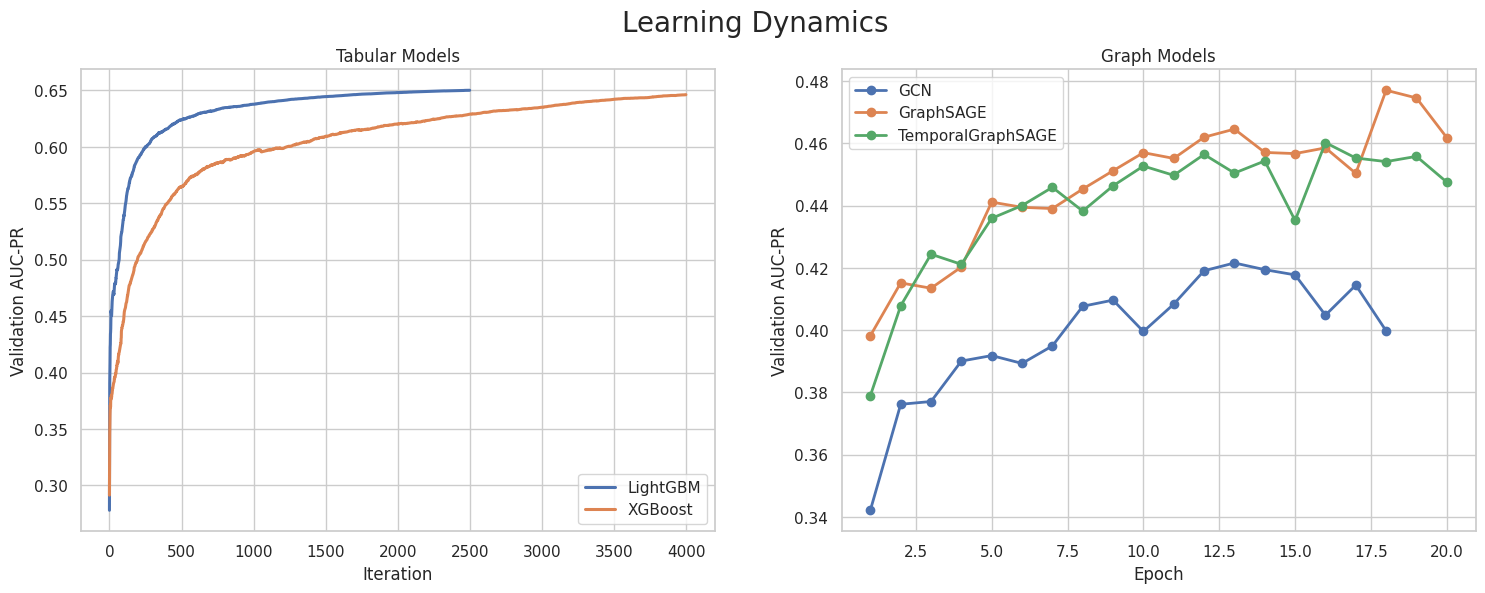

In [15]:
# Figure 1.2 - Learning Dynamics
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Left panel: tabular baselines
axes[0].plot(
    phase1_lgbm_history["valid"]["average_precision"],
    label="LightGBM",
    linewidth=2.2,
)
axes[0].plot(
    phase1_xgb_history["valid"]["aucpr"],
    label="XGBoost",
    linewidth=2.2,
)
axes[0].set_title("Tabular Models")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Validation AUC-PR")
axes[0].legend()

# Right panel: graph models from the frozen Phase 2 history CSVs
graph_history_specs = [
    ("GCN", PHASE2_INPUT_ROOT / "artifacts" / "phase02_graph_models" / "full_GCN_history.csv"),
    ("GraphSAGE", PHASE2_INPUT_ROOT / "artifacts" / "phase02_graph_models" / "full_GraphSAGE_history.csv"),
    ("TemporalGraphSAGE", PHASE2_INPUT_ROOT / "artifacts" / "phase02_graph_models" / "full_TemporalGraphSAGE_history.csv"),
]

for model_label, history_path in graph_history_specs:
    history_df = pd.read_csv(history_path)
    axes[1].plot(
        history_df["epoch"],
        history_df["valid_auc_pr"],
        marker="o",
        linewidth=2.0,
        label=model_label,
    )

axes[1].set_title("Graph Models")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Validation AUC-PR")
axes[1].legend()

fig.suptitle("Learning Dynamics", fontsize=20)
save_figure(fig, "figure_1_2_learning_dynamics")

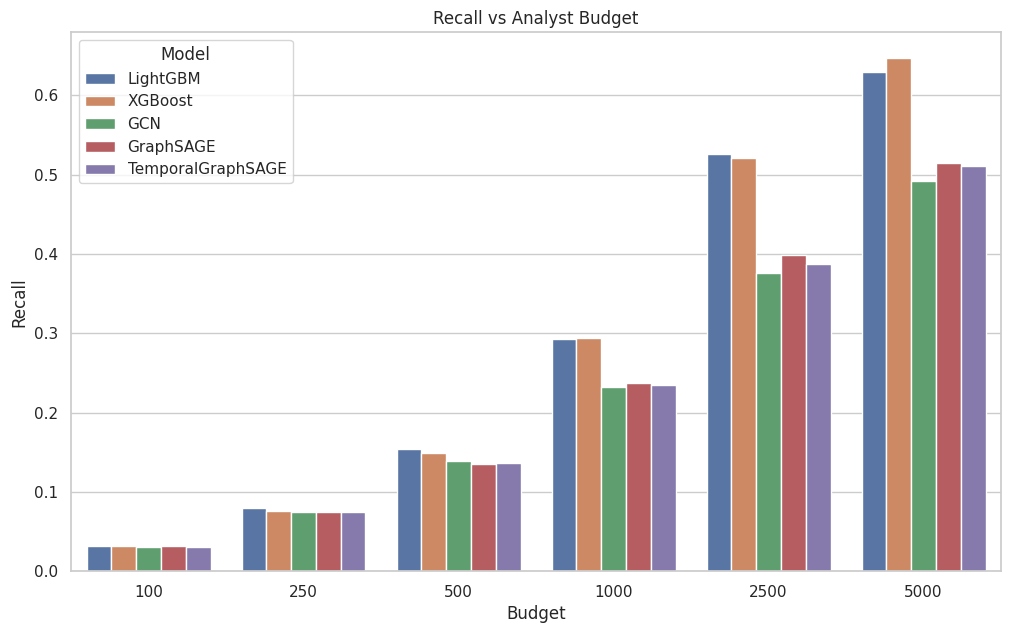

In [16]:
# Figure 1.3 - Recall vs Analyst Budget (grouped bar chart)
budget_rows = []
for model_name, score_col in curve_specs:
    for budget in ANALYST_BUDGETS:
        budget_rows.append(
            {
                "Budget": budget,
                "Model": model_name,
                "Recall": recall_at_k(y_test, test_prediction_df[score_col].to_numpy(), budget),
            }
        )

budget_df = pd.DataFrame(budget_rows)

fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(data=budget_df, x="Budget", y="Recall", hue="Model", ax=ax)
ax.set_title("Recall vs Analyst Budget")
ax.set_xlabel("Budget")
ax.set_ylabel("Recall")
ax.legend(title="Model")
save_figure(fig, "figure_1_3_recall_vs_analyst_budget")